In [1]:
using BenchmarkTools
using Profile
using JLD2
using Pkg
using Plots

In [2]:
Pkg.activate("../.."); using JPEC

  Activating project at `~/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia`


In [3]:
@load "benchmark_inputs.jld2" benchmark_inputs

(; wv_block, mpert, mtheta_eq, mthvac, complex_flag, kernelsign,
                wall_flag, farwall_flag, grri, xzpts, ahg_file, dir_path,
                vac_inputs, wall_settings,
                n, ipert_n, psifac) = benchmark_inputs


JPEC.DCON.VacuumBenchmarkInputs(ComplexF64[0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], 34, 256, 512, true, 1.0, false, true, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0], "ahg2msc_dcon.out", "/Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/examples/DIIID_ideal_example", JPEC.Vacuum.VacuumInput([2.2891936601349068, 2.2885180072000386, 2.286268365351824, 2.2824678688740376, 2.277185509525792, 2.2704366419999804, 2.2624000121538446, 2.2530764807150523, 2.24266292967996, 2.2311832448940185  …  2.2344169226639146, 2.2445037241381702, 2.2539936148023947, 2.262609333198052, 2.27020001845327, 2.2767337496320175, 2.2820028147246987, 2.2858882171987323, 2.2883170327073485, 2.2891936601349068], [0.024419144244

In [4]:
# Define range of n values to test
n_values = [1, 2, 3, 5, 10, 15, 20, 30, 50]

# Store results
fortran_times = Float64[]
fortran_stdevtimes = Float64[]
fortran_allocs = Int[]
fortran_memory = Float64[]

julia_times = Float64[]
julia_stdevtimes = Float64[]
julia_allocs = Int[]
julia_memory = Float64[]

# Run benchmarks for each n value
for n_test in n_values
	println("Benchmarking n = $n_test")
	
	# Benchmark Fortran version
	JPEC.Vacuum.set_dcon_params(mtheta_eq, vac_inputs.mlow, vac_inputs.mhigh, 
								 n_test, vac_inputs.qa, vac_inputs.r, 
								 vac_inputs.z, vac_inputs.delta)
	
	b_fortran = @benchmark JPEC.Vacuum.mscvac($wv_block, $mpert, $mtheta_eq, $mthvac, 
											   $complex_flag, $kernelsign, $wall_flag, 
											   $farwall_flag, $grri, $xzpts, $ahg_file, $dir_path)
	
	push!(fortran_times, median(b_fortran).time / 1e9)
	push!(fortran_stdevtimes, std(b_fortran).time / 1e9)
	push!(fortran_allocs, median(b_fortran).allocs)
	push!(fortran_memory, median(b_fortran).memory / 1e6)
	
	JPEC.Vacuum.unset_dcon_params()
	
	# Benchmark Julia version
	vac_inputs_test = deepcopy(vac_inputs)
	vac_inputs_test.n = n_test
	
	b_julia = @benchmark JPEC.Vacuum.compute_vacuum_response($wall_settings, $vac_inputs_test, $dir_path)
	
	push!(julia_times, median(b_julia).time / 1e9)
	push!(julia_stdevtimes, std(b_julia).time / 1e9)
	push!(julia_allocs, median(b_julia).allocs)
	push!(julia_memory, median(b_julia).memory / 1e6)
end


Benchmarking n = 1
   > Vacuum code overriding r 1.00E+00 from vac.in, to be 0


┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

Benchmarking n = 2


┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

Benchmarking n = 3


...

┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

Benchmarking n = 30


┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

Benchmarking n = 50


┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

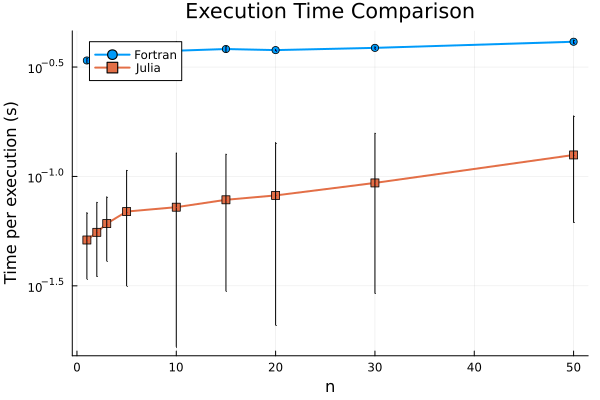

In [5]:
# Time comparison
p1 = plot(n_values, fortran_times, label="Fortran", marker=:circle, 
		  xlabel="n", ylabel="Time per execution (s)", title="Execution Time Comparison",
		  legend=:topleft, linewidth=2, yscale=:log10)
plot!(p1, n_values, julia_times, label="Julia", marker=:square, linewidth=2)
# Add error bars for Fortran
scatter!(p1, n_values, fortran_times, yerror=fortran_stdevtimes, 
		 label="", color=:blue, markersize=0)

# Add error bars for Julia
scatter!(p1, n_values, julia_times, yerror=julia_stdevtimes, 
		 label="", color=:red, markersize=0)

In [ ]:
# Define range of mhigh values to test
mhigh_values = [16, 32, 64, 128, 256, 512]

# Store results
fortran_mhigh_times = Float64[]
fortran_mhigh_stdevtimes = Float64[]
fortran_mhigh_allocs = Int[]
fortran_mhigh_memory = Float64[]

julia_mhigh_times = Float64[]
julia_mhigh_stdevtimes = Float64[]
julia_mhigh_allocs = Int[]
julia_mhigh_memory = Float64[]

# Run benchmarks for each mhigh value
for mhigh_test in mhigh_values
	println("Benchmarking mhigh = $mhigh_test")
	
	# Calculate mpert based on mhigh
	mpert_test = mhigh_test - vac_inputs.mlow
	
	# Benchmark Fortran version
	JPEC.Vacuum.set_dcon_params(mtheta_eq, vac_inputs.mlow, mhigh_test, 
								 1, vac_inputs.qa, vac_inputs.r, 
								 vac_inputs.z, vac_inputs.delta)
	
	b_fortran = @benchmark JPEC.Vacuum.mscvac($wv_block, $mpert_test, $mtheta_eq, $mthvac, 
											   $complex_flag, $kernelsign, $wall_flag, 
											   $farwall_flag, $grri, $xzpts, $ahg_file, $dir_path)
	
	push!(fortran_mhigh_times, median(b_fortran).time / 1e9)
	push!(fortran_mhigh_stdevtimes, std(b_fortran).time / 1e9)
	push!(fortran_mhigh_allocs, median(b_fortran).allocs)
	push!(fortran_mhigh_memory, median(b_fortran).memory / 1e6)
	
	JPEC.Vacuum.unset_dcon_params()
	
	# Benchmark Julia version
	vac_inputs_test = deepcopy(vac_inputs)
	vac_inputs_test.mhigh = mhigh_test
	vac_inputs_test.mpert = mhigh_test - vac_inputs_test.mlow
	
	b_julia = @benchmark JPEC.Vacuum.compute_vacuum_response($wall_settings, $vac_inputs_test, $dir_path)
	
	push!(julia_mhigh_times, median(b_julia).time / 1e9)
	push!(julia_mhigh_stdevtimes, std(b_julia).time / 1e9)
	push!(julia_mhigh_allocs, median(b_julia).allocs)
	push!(julia_mhigh_memory, median(b_julia).memory / 1e6)
end

Benchmarking mhigh = 16


┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/julia/JPEC.worktrees/vacuum_julia/src/Vacuum/Vacuum_init.jl:107
┌ Info: Using no wall
└ @ JPEC.Vacuum /Users/pharr/Projects/GPEC_dev/

In [ ]:
# Time comparison for mhigh scan
p2 = plot(mhigh_values, fortran_mhigh_times, label="Fortran", marker=:circle, 
		  xlabel="mhigh", ylabel="Time per execution (s)", title="Execution Time vs mhigh",
		  legend=:topleft, linewidth=2, yaxis=:log)
plot!(p2, mhigh_values, julia_mhigh_times, label="Julia", marker=:square, linewidth=2)

# Add error bars for Fortran
scatter!(p2, mhigh_values, fortran_mhigh_times, yerror=fortran_mhigh_stdevtimes, 
		 label="", color=:blue, markersize=0)

# Add error bars for Julia
scatter!(p2, mhigh_values, julia_mhigh_times, yerror=julia_mhigh_stdevtimes, 
		 label="", color=:red, markersize=0)
